# Task 3: Cat vs Dog Image Classification using Support Vector Machine (SVM)

## Objective
Implement a Support Vector Machine (SVM) classifier to classify images of cats and dogs.

## Dataset
Microsoft Cats and Dogs Dataset

## Steps Performed
1. Download and extract dataset
2. Load and preprocess images
3. Resize images to a fixed size
4. Convert images into feature vectors
5. Split data into training and testing sets
6. Train SVM classifier
7. Evaluate model performance
8. Visualize predictions


In [ ]:
import os
import cv2
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## Download Dataset

Downloading Microsoft Cats and Dogs Dataset.

In [ ]:
!wget -O kagglecatsanddogs_5340.zip \
"https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"

--2026-06-20 11:50:27--  https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.0.206.63, 2600:1409:3c00:c8c::317f, 2600:1409:3c00:c80::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.0.206.63|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘kagglecatsanddogs_5340.zip’

kagglecatsanddogs_5 100%[===================>] 786.67M   125MB/s    in 8.6s    

2026-06-20 11:50:36 (91.4 MB/s) - ‘kagglecatsanddogs_5340.zip’ saved [824887076/824887076]



## Extract Dataset

In [ ]:
with zipfile.ZipFile("kagglecatsanddogs_5340.zip", "r") as zip_ref:
    zip_ref.extractall("/content")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


## Verify Dataset Structure

In [ ]:
dataset_path = "/content/PetImages"

print(os.listdir(dataset_path))

['Dog', 'Cat']


## Load and Preprocess Images

Images are resized to 64×64 pixels and converted into feature vectors.

In [ ]:
IMG_SIZE = 32

data = []
labels = []
display_images = [] # New list to store images for visualization

categories = ["Cat", "Dog"]

MAX_IMAGES_PER_CLASS = 1500

In [ ]:
for category in categories:

    folder_path = os.path.join(dataset_path, category)

    label = categories.index(category)

    count = 0

    for image_name in os.listdir(folder_path):

        try:

            image_path = os.path.join(folder_path, image_name)

            image = cv2.imread(image_path)

            if image is None:
                continue

            # Resize for display and HOG feature extraction
            image_resized_for_display = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            display_images.append(image_resized_for_display) # Store the resized color image

            image_gray = cv2.cvtColor(image_resized_for_display, cv2.COLOR_BGR2GRAY)
            image_gray_resized_for_hog = cv2.resize(image_gray, (64, 64)) # Resize to 64x64 for HOG

            from skimage.feature import hog

            features = hog(
                image_gray_resized_for_hog,
                orientations=9,
                pixels_per_cell=(8, 8),
                cells_per_block=(2, 2),
                block_norm='L2-Hys'
            )

            data.append(features)
            labels.append(label)

            count += 1

            if count >= MAX_IMAGES_PER_CLASS:
                break

        except:
            pass

    print(f"{category} Images Loaded:", count)

Cat Images Loaded: 1500
Dog Images Loaded: 1500


## Convert Data into NumPy Arrays

In [ ]:
X = np.array(data)
y = np.array(labels)
X_display = np.array(display_images) # Convert display images to NumPy array

print("Feature Shape:", X.shape)
print("Labels Shape:", y.shape)
print("Display Image Shape:", X_display.shape) # Print shape of display images

Feature Shape: (3000, 1764)
Labels Shape: (3000,)
Display Image Shape: (3000, 32, 32, 3)


## Split Dataset into Training and Testing Sets

In [ ]:
X_train, X_test, y_train, y_test, X_display_train, X_display_test = train_test_split(
    X,
    y,
    X_display, # Include X_display in the split
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))
print("Display Test Samples:", len(X_display_test)) # Verify split

Training Samples: 2400
Testing Samples: 600
Display Test Samples: 600


## Feature Scaling

Scaling improves SVM performance.

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train Support Vector Machine Model

In [ ]:
svm_model = SVC(
    kernel="rbf",
    C=100,
    gamma=0.001
)

svm_model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


## Make Predictions

In [ ]:
y_pred = svm_model.predict(X_test)

## Model Accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 73.50%


## Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Cat", "Dog"]
    )
)

              precision    recall  f1-score   support

         Cat       0.72      0.77      0.74       300
         Dog       0.75      0.70      0.73       300

    accuracy                           0.73       600
   macro avg       0.74      0.74      0.73       600
weighted avg       0.74      0.73      0.73       600



## Confusion Matrix

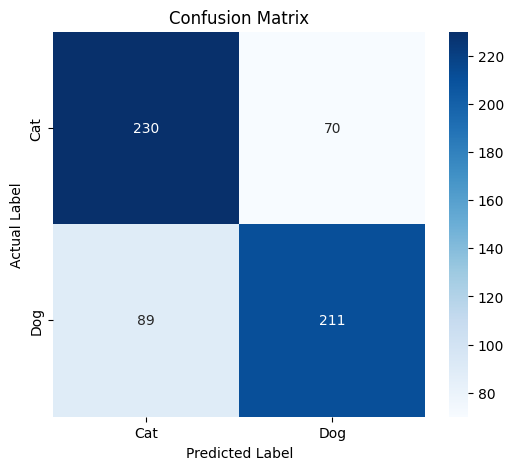

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Cat","Dog"],
    yticklabels=["Cat","Dog"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## Visualize Sample Predictions

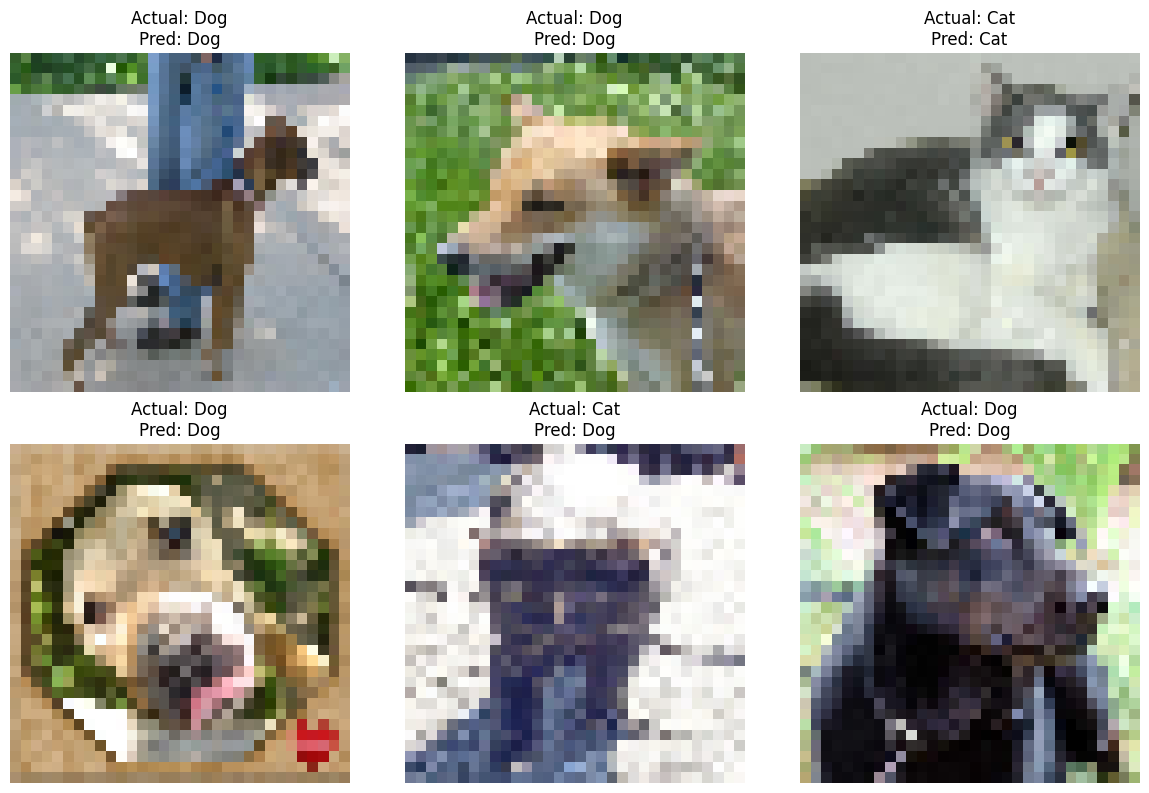

In [125]:
plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    # Use the pre-saved image for display directly from X_display_test
    img_to_show = X_display_test[i]

    prediction = svm_model.predict(
        X_test[i].reshape(1,-1)
    )[0]

    label = "Dog" if prediction == 1 else "Cat"

    # Convert BGR to RGB for matplotlib display
    plt.imshow(cv2.cvtColor(img_to_show, cv2.COLOR_BGR2RGB))
    actual = "Dog" if y_test[i] == 1 else "Cat"
    predicted = "Dog" if prediction == 1 else "Cat"

    plt.title(f"Actual: {actual}\nPred: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Conclusion

Images were resized, converted to grayscale, and transformed into HOG (Histogram of Oriented Gradients) features. These features were scaled and used to train an SVM classifier. The model achieved approximately 73.5% accuracy in distinguishing cats and dogs. This demonstrates the effectiveness of combining HOG feature extraction with SVM for image classification tasks.